In [4]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from academic_success import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data


In [6]:
train_df = data.load_train()
print(f"{len(train_df)} rows, {train_df.shape[1]} columns")
train_df.head()

76518 rows, 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1,1,1,9238,1,1,126.0,1,1,19,5,5,122.6,0,0,0,1,0,1,18,0,0,6,6,6,14.500000,0,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,17,1,9238,1,1,125.0,1,19,19,9,9,119.8,1,0,0,1,0,0,18,0,0,6,8,4,11.600000,0,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,1,17,2,9254,1,1,137.0,1,3,19,2,3,144.7,0,0,0,1,1,0,18,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,1,1,3,9500,1,1,131.0,1,19,3,3,2,126.1,1,0,0,1,0,1,18,0,0,7,9,7,12.591250,0,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,1,1,2,9500,1,1,132.0,1,19,37,4,9,120.1,1,0,0,1,0,0,18,0,0,7,12,6,12.933333,0,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


### Concept: what "1st sem" / "2nd sem" mean, and why 2 semesters can predict a multi-year outcome

Each semester has 6 fields: `credited` (units credited without an exam —
transfer credit/exemptions), `enrolled`, `evaluations` (number of
assessments taken), `approved` (units passed), `grade` (average grade
across evaluated units), and `without evaluations` (units enrolled but
never evaluated — disengagement, distinct from being evaluated _and_
failing).

"1st sem"/"2nd sem" here means the student's **first academic year** —
these degree programs typically run 3+ years, and the target
(Dropout/Enrolled/Graduate) is recorded at the _end_ of that multi-year
program. Predicting a multi-year outcome from only the first year isn't a
limitation of the dataset — it's the point: this is a realistic
**early-warning dropout prediction** setup. An institution doesn't want to
wait until year 3 to notice a student is at risk, so the actionable
question is "using only admission data plus the first year, can we flag
at-risk students early enough to help them?" It's also why this project's
`approval_rate_*_sem` and `grade_trend` features (Section 4) matter so
much — a student's _trajectory_ within that first year is a meaningful
signal for years the model never directly observes.


## 2. Explore the data (EDA)

**Exploratory Data Analysis (EDA)** means looking at a dataset _before_
building any model — checking what values each column actually takes, how
the target is distributed, whether anything is missing, and whether
anything looks wrong. Skipping this step is one of the most common ways a
modeling project goes wrong: a model can't fix a problem in the data it
never surfaced to you.


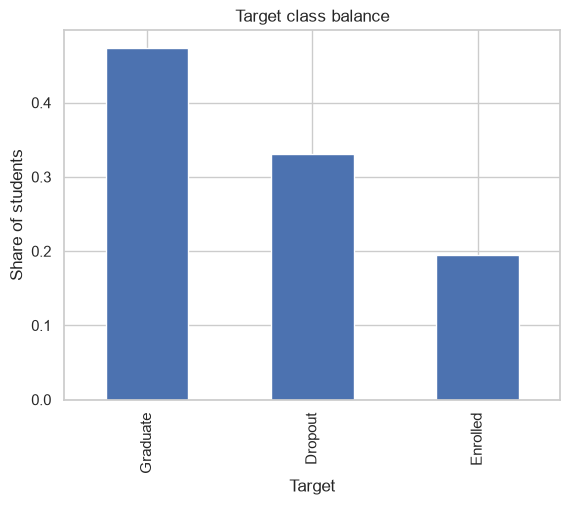

In [7]:
train_df[config.TARGET_COL].value_counts(normalize=True).plot.bar(
    title="Target class balance"
)
plt.ylabel("Share of students")
plt.show()

### Concept: why "accuracy" isn't enough for imbalanced classes

The bar chart above shows the three classes are **imbalanced** — Graduate
is the most common outcome, Enrolled the least. This matters more than it
might seem, because of how **accuracy** is defined:

```
accuracy = (correct predictions) / (total predictions)
```

Imagine a "model" that always predicts "Graduate" and nothing else. If
Graduate makes up ~47% of students, that lazy model would score ~47%
accuracy — sounds mediocre, but it completely fails at the _other_ two
classes it's supposed to predict, and a genuinely useless model can still
look deceptively okay by this one number.

This is why every model comparison in this notebook uses **macro-averaged
F1** instead. To define it, first define two per-class metrics:

- **Precision** — of everything the model labeled as class X, what
  fraction actually _was_ X? `precision = TP / (TP + FP)`
- **Recall** — of everything that actually _was_ class X, what fraction
  did the model correctly catch? `recall = TP / (TP + FN)`
- **F1 score** — the harmonic mean of precision and recall, punishing
  models that are good at one but bad at the other:
  `F1 = 2 * (precision * recall) / (precision + recall)`

**Macro-averaging** then computes F1 separately for each class and takes a
plain (unweighted) average across classes — so a model that ignores the
minority "Enrolled" class to do well on "Graduate" can no longer hide that
weakness behind a big class's good score. Section 7 below makes this
concrete with a real confusion matrix and per-class report.


In [8]:
missing = train_df[config.RAW_FEATURE_COLS].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:" if len(missing) else "No missing values found.")
missing

No missing values found.


Series([], dtype: int64)

### Concept: why missing data matters

Most machine learning models can't handle a missing value directly — they
need _some_ number in every cell. The two broad strategies are:

- **Drop** the column (if it's missing so often that its remaining values
  aren't trustworthy) or drop the row (if very few rows are affected).
- **Impute** — fill the gap with a reasonable substitute (e.g. the column's
  median or most common value), so the row can still be used.

Which strategy is right depends on _how much_ is missing and _why_. See
Section 3 for what this dataset actually needs.


In [5]:
numeric_summary = train_df[config.NUMERIC_COLS].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),76518.0,132.378766,10.995328,95.00,125.000000,133.100000,140.000000,190.000
Admission grade,76518.0,125.363971,12.562328,95.00,118.000000,124.600000,132.000000,190.000
Age at enrollment,76518.0,22.278653,6.889241,17.00,18.000000,19.000000,23.000000,70.000
Curricular units 1st sem (credited),76518.0,0.188871,1.175296,0.00,0.000000,0.000000,0.000000,20.000
Curricular units 1st sem (enrolled),76518.0,5.891516,1.671776,0.00,5.000000,6.000000,6.000000,26.000
Curricular units 1st sem (evaluations),76518.0,7.352362,3.508292,0.00,6.000000,7.000000,9.000000,45.000
Curricular units 1st sem (approved),76518.0,4.178520,2.687995,0.00,2.000000,5.000000,6.000000,26.000
Curricular units 1st sem (grade),76518.0,9.995862,5.264224,0.00,10.666667,12.166667,13.314286,18.875
Curricular units 1st sem (without evaluations),76518.0,0.057960,0.408490,0.00,0.000000,0.000000,0.000000,12.000
Curricular units 2nd sem (credited),76518.0,0.137053,0.933830,0.00,0.000000,0.000000,0.000000,19.000


### Concept: what `describe()` tells you, and why it matters later

Look at the `mean` and `std` (standard deviation) columns above: some
features (like curricular unit _counts_) range from 0 to maybe 20, while
others (like `Admission grade`) range from 0 to 200. This difference in
**scale** matters for some models — a linear model like Logistic Regression
(Section 6) treats a one-unit change the same everywhere, so a feature
naturally ranging in the hundreds can dominate one ranging in single digits
purely because of its scale, not because it's actually more important. This
is why the shared preprocessing pipeline (`src/academic_success/features.py`)
standardizes every numeric feature (subtract the mean, divide by the
standard deviation) before fitting a model — see Section 5 once we start
building pipelines. Tree-based models (Sections 7 onward) don't have this
issue, since they split on thresholds rather than computing weighted sums.


## 3. Data cleaning notes

- The "categorical" columns (`Marital status`, `Course`, `Nacionality`, ...)
  arrive as **integer codes**, not strings. This is a classic data-cleaning
  trap: if you feed a code like `Course = 9254` straight into a model that
  expects numbers to have a meaningful order and distance (like a linear
  model, or if you accidentally treat it as if it were a count), the model
  will assume course code 9254 is "between" 9253 and 9255 and closer to
  9200 than to 3, none of which the codes actually mean. The fix is
  **one-hot encoding**: turn one categorical column with _k_ possible codes
  into _k_ separate 0/1 columns ("is it course 9254? is it course 3?" ...),
  so the model only ever sees "is this category present," never a false
  numeric order. See `build_preprocessor()` in `features.py`.
- No duplicate rows or obviously invalid values (e.g., negative ages) were
  found in this dataset, so no row-dropping was needed. If you're adapting
  this notebook to a different dataset, this is exactly the step where
  you'd add `df.drop_duplicates()` / range checks.
- Several categorical columns (`Course`, occupation codes, `Nacionality`)
  have a long tail of rare codes. One-hot-encoding a code only a handful of
  students share creates a column the model almost never gets to learn
  from, and risks an unseen rare code at inference time. `RareCategoryGrouper`
  (in `features.py`) collapses any code below 1% frequency into a shared
  "rare" bucket before one-hot encoding — learned from training data only.


## 4. Feature engineering

**Feature engineering** means deriving new columns from the raw data that
expose a pattern more directly than the raw columns do on their own. It's
one of the highest-leverage steps in a tabular ML project — often more
impactful than which model you choose.

Two students who both "enroll in 6 units" look identical on the raw
columns, but one who _passes_ all 6 and one who passes 1 are very
different risk profiles. `src/academic_success/features.py` derives ratio
and trend features that capture a student's trajectory across the two
semesters instead of treating each semester as an isolated snapshot — see
`report/report.qmd` for the full rationale behind each one.


In [6]:
X, y = data.split_features_target(train_df)

engineered_preview = features.FeatureEngineer().fit_transform(X)
engineered_preview[features.ENGINEERED_NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
approval_rate_1st_sem,76518.0,0.668332,0.392996,0.0,0.400000,0.833333,1.000000,2.000000
approval_rate_2nd_sem,76518.0,0.633708,0.405538,0.0,0.166667,0.833333,1.000000,5.000000
total_units_approved,76518.0,8.185721,5.354344,0.0,3.000000,10.000000,12.000000,43.000000
total_units_enrolled,76518.0,11.824930,3.262742,0.0,10.000000,12.000000,12.000000,46.000000
grade_trend,76518.0,-0.369777,2.556932,-18.0,-0.500000,0.000000,0.333333,16.500000
no_evaluation_ratio,76518.0,0.007267,0.049363,0.0,0.000000,0.000000,0.000000,1.263158
max_parental_qualification,76518.0,25.988134,13.950759,1.0,19.000000,37.000000,37.000000,44.000000


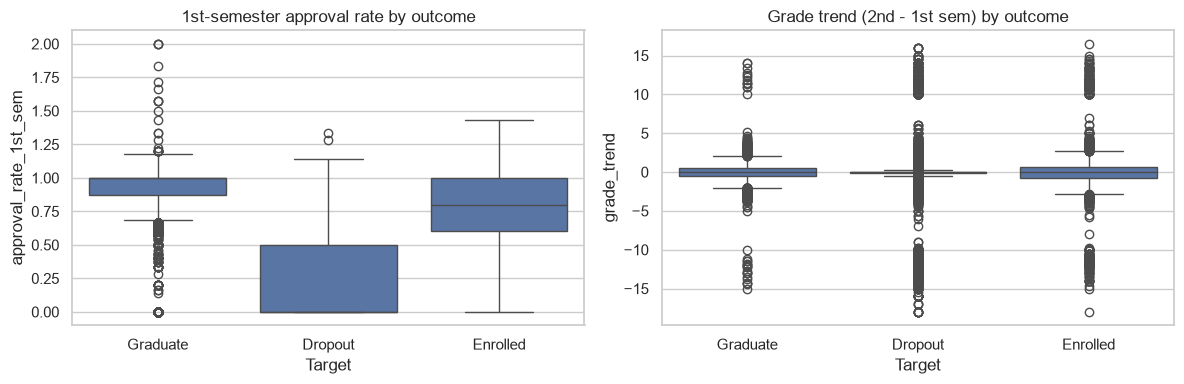

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=engineered_preview, x=y, y="approval_rate_1st_sem", ax=axes[0])
axes[0].set_title("1st-semester approval rate by outcome")
sns.boxplot(data=engineered_preview, x=y, y="grade_trend", ax=axes[1])
axes[1].set_title("Grade trend (2nd - 1st sem) by outcome")
plt.tight_layout()
plt.show()

### Concept: reading a boxplot

Each box above shows one outcome group's distribution of a feature: the
line inside the box is the **median** (middle value), the box spans the
**25th to 75th percentile** (the middle 50% of students), and the
"whiskers" extend to the typical range beyond that. As expected, students
who eventually drop out show a visibly lower 1st-semester approval rate and
a flatter or negative grade trend compared to students who graduate —
exactly the signal these engineered features were designed to expose to
the model.


## 5. Why cross-validation? (a detour before we train anything)

Before fitting a single model, it's worth answering a question a lot of
beginners skip: **why not just fit a model on all the data, and check how
often it's right on that same data?**

### Concept: overfitting and underfitting

- **Underfitting** — the model is too simple to capture the real pattern
  (e.g. it barely beats guessing the majority class everywhere).
- **Overfitting** — the model is _too_ flexible, and starts memorizing
  quirks specific to the exact rows it was trained on — quirks that won't
  generalize to a new student it's never seen. A model that has
  memorized its training data can score close to 100% _on that data_ while
  doing much worse on anyone new — which is exactly why scoring a model on
  the same data it was trained on is misleading.

The demo below makes this concrete: it fits a model on the _full_ dataset,
then compares its in-sample score (evaluated on the very rows it trained
on) against a proper cross-validated score (evaluated on rows held out from
each training fold).


In [8]:
from sklearn.metrics import f1_score

# In-sample score: fit and evaluate on the exact same rows — optimistic,
# because the model has already "seen the answers" for every row it's
# being scored on.
demo_pipeline = model.build_pipeline(model.default_estimator())
demo_pipeline.fit(X, y)
in_sample_f1 = f1_score(y, demo_pipeline.predict(X), average="macro")

# Cross-validated score: never evaluated on rows it trained on this fold.
cv_result = model.cross_validate_pipeline(X, y, cv=5)

print(f"In-sample macro F1 (misleadingly optimistic): {in_sample_f1:.4f}")
print(f"5-fold cross-validated macro F1 (honest estimate): {cv_result['f1_macro_mean']:.4f}")

In-sample macro F1 (misleadingly optimistic): 0.8166
5-fold cross-validated macro F1 (honest estimate): 0.7949


### Concept: k-fold cross-validation

**Cross-validation** answers "how well will this model do on data it
hasn't seen?" without needing to wait for genuinely new data. **k-fold**
cross-validation (this project uses k=5) works like this:

1. Split the training data into 5 equal-sized chunks ("folds").
2. For each fold in turn: train the model on the _other_ 4 folds, then
   score it on the held-out fold it never saw.
3. Average the 5 resulting scores.

Every row gets scored exactly once, by a model that never trained on it —
that's what makes the resulting number an honest estimate of real-world
performance, not an inflated one.

### Concept: pipelines and data leakage

Notice every model in this notebook is built through
`model.build_pipeline(...)`, which chains feature engineering →
preprocessing (impute + scale) → the classifier into one object
(`sklearn.pipeline.Pipeline`). This matters for cross-validation
specifically: if you computed, say, the median used for imputation from
_all_ the data before splitting into folds, information from the held-out
fold (its values contributed to that median) would leak into training —
making the validation score subtly optimistic. A `Pipeline` re-fits every
preprocessing step (median, scaler, rare-category groupings, ...) from
scratch on only each fold's training portion, so nothing from the held-out
fold ever leaks in.


## 6. Baseline model: Logistic Regression

Always start with a simple, interpretable baseline before reaching for a
more complex model — it tells you whether the extra complexity is actually
earning its keep, and gives you a sanity-checkable reference point.

### Concept: what Logistic Regression actually does

Despite the name, Logistic Regression is a **classification** model, not a
regression one. For each class, it learns a weight for every input feature,
multiplies each feature by its weight and adds them up (a _linear_
combination — geometrically, this defines a straight decision boundary
through feature space), then squashes that sum into a probability with a
"softmax" function (a multi-class generalization of the logistic/sigmoid
curve) so the three class probabilities add up to 1. It's fast, its
learned weights are directly inspectable (a large positive weight on
"approval rate" means higher approval rate pushes the prediction toward
that class), and it works well when classes really are separated by
roughly straight boundaries in feature space — but it can't capture
more complex, curved, or interacting relationships the way tree-based
models can.


In [9]:
from sklearn.linear_model import LogisticRegression

baseline_scores = model.cross_validate_pipeline(
    X, y, estimator=LogisticRegression(max_iter=1000, random_state=config.RANDOM_SEED), cv=5
)
baseline_scores

{'accuracy_mean': np.float64(0.8234794278761216),
 'accuracy_std': np.float64(0.0022593256500029893),
 'f1_macro_mean': np.float64(0.7815952540865527),
 'f1_macro_std': np.float64(0.002934449616636484)}

## 7. Stronger model: gradient-boosted trees

### Concept: decision trees

A **decision tree** predicts by asking a sequence of yes/no questions about
the features ("is `approval_rate_2nd_sem` above 0.5? if yes, is
`Tuition fees up to date` == Yes? ...") until it reaches a leaf holding a
prediction. Unlike a linear model, trees naturally capture _non-linear_
patterns and _interactions_ between features (a rule can depend on two
features at once) without you having to engineer that interaction by hand.
A single tree, though, tends to overfit badly — it can keep splitting
until every leaf is a memorized answer for one training row.

### Concept: boosting

**Gradient boosting** fixes that by combining _many_ small, deliberately
weak trees, built **sequentially**: each new tree focuses on correcting the
mistakes the trees so far are still making, rather than being trained
independently. `HistGradientBoostingClassifier` (this project's default
model) is a modern, fast implementation of that idea, which speeds up
finding the best split point by first grouping each feature's values into
a small number of bins (a histogram) instead of considering every possible
threshold.


In [10]:
gbm_scores = model.cross_validate_pipeline(X, y, cv=5)  # uses model.default_estimator()
gbm_scores

{'accuracy_mean': np.float64(0.8316605031406195),
 'accuracy_std': np.float64(0.0020516712395298215),
 'f1_macro_mean': np.float64(0.7949458554455647),
 'f1_macro_std': np.float64(0.002906390187621778)}

In [11]:
comparison = pd.DataFrame(
    [
        {"model": "Logistic Regression", **baseline_scores},
        {"model": "HistGradientBoostingClassifier", **gbm_scores},
    ]
).set_index("model")
comparison

,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
model,,,,
Logistic Regression,0.823479,0.002259,0.781595,0.002934
HistGradientBoostingClassifier,0.831661,0.002052,0.794946,0.002906


If the gradient-boosted model's macro-F1 meaningfully beats the linear
baseline, that justifies the added complexity (and reduced
interpretability) — record the numbers you see here in
`report/report.qmd`'s Results table.


### Concept: confusion matrices and per-class metrics, made concrete

Section 2 defined precision, recall, and macro-F1 in the abstract. Here's
what they look like for a real trained model, on data it wasn't trained on
— a genuine held-out test split (not cross-validation this time, just a
single train/test split, so we can look at one concrete set of predictions
side by side with the truth).


              precision    recall  f1-score   support

     Dropout       0.89      0.83      0.86      5059
    Enrolled       0.66      0.61      0.63      2988
    Graduate       0.85      0.92      0.89      7257

    accuracy                           0.83     15304
   macro avg       0.80      0.79      0.79     15304
weighted avg       0.83      0.83      0.83     15304



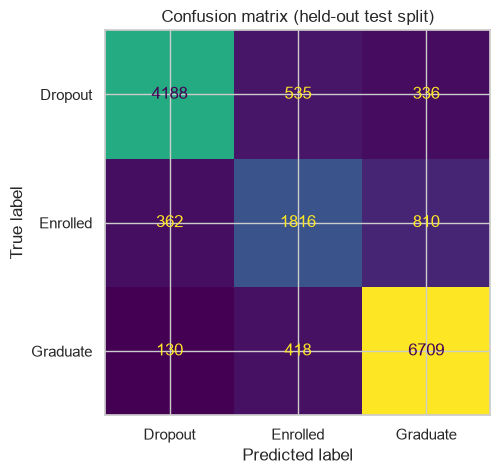

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

X_train_cm, X_test_cm, y_train_cm, y_test_cm = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_SEED
)

cm_pipeline = model.build_pipeline(model.default_estimator())
cm_pipeline.fit(X_train_cm, y_train_cm)
cm_predictions = cm_pipeline.predict(X_test_cm)

print(classification_report(y_test_cm, cm_predictions))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_cm, cm_predictions, labels=config.TARGET_CLASSES, ax=ax, colorbar=False
)
plt.title("Confusion matrix (held-out test split)")
plt.show()

**How to read the confusion matrix:** each row is the _true_ class, each
column is the _predicted_ class. The diagonal (top-left to bottom-right) is
every correct prediction; anything off the diagonal is a specific kind of
mistake (e.g. row "Dropout", column "Enrolled" = students who actually
dropped out but were predicted as still enrolled). This is far more
informative than a single accuracy number, because it shows _which_
classes get confused with _which other_ classes.

**How to read the classification report above it:** `support` is simply
how many true examples of that class exist in the test split — the
denominator behind recall. Compare each class's precision and recall
side-by-side: a class with high precision but low recall means the model
is _cautious_ about predicting it (rarely wrong when it does, but misses
many true cases); high recall but low precision means the opposite (catches
most true cases, but with a lot of false alarms).


## 8. Fit the final pipeline and save it

Cross-validation (Section 5) told us how well this _kind_ of model
generalizes — but every one of those 5 folds still only trained on 80% of
the available data. For the model we actually ship, there's no reason to
hold anything back: refit one final pipeline on _all_ the training data,
which the app and submission script will load.


In [13]:
final_pipeline = model.train_pipeline(X, y)
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/academic_success/models/model.joblib


## 9. Sanity-check a held-out prediction

Quick reminder that this is a smoke test, not a real evaluation: five
already-seen training rows, just confirming the saved pipeline loads and
predicts without error. Section 7's confusion matrix and Section 5's
cross-validation are the actual performance evidence.


In [14]:
sample = X.sample(5, random_state=config.RANDOM_SEED)
predictions = final_pipeline.predict(sample)
pd.DataFrame({"predicted": predictions, "actual": y.loc[sample.index]})

,predicted,actual
id,,
41775,Graduate,Graduate
45794,Dropout,Dropout
46620,Enrolled,Enrolled
18945,Dropout,Dropout
38446,Graduate,Enrolled


## 10. Broader model comparison

Following the classic Titanic tutorials' "try many algorithms, compare
systematically" approach: rather than jumping straight from a linear
baseline to one gradient-boosted model, sweep every model family this
project supports and let the numbers pick the winner instead of assuming
one.

### Concept: what distinguishes each of these 8 models

- **Logistic Regression** — one straight-line (linear) decision boundary
  per class; see Section 6.
- **Random Forest** — **bagging**: trains many _independent_ decision
  trees, each on a random subset of rows and a random subset of features,
  then averages their votes. Averaging many high-variance, low-bias trees
  cancels out their individual overfitting.
- **AdaBoost** — an early boosting method: after each tree, it _increases
  the weight_ of the training rows the model got wrong, so the next tree
  is forced to focus on the hard cases.
- **Gradient Boosting** — the more general boosting idea Section 7
  introduced: each new tree fits the _residual error_ (how wrong the
  current ensemble still is) rather than reweighting rows.
- **HistGradientBoosting** — gradient boosting with histogram-binned
  features for speed (Section 7's default).
- **XGBoost**, **LightGBM**, **CatBoost** — three independent, widely-used
  libraries that all implement gradient boosting with their own
  engineering optimizations and regularization choices (e.g. CatBoost's
  native handling of categorical features, LightGBM's leaf-wise tree
  growth). Differences between them tend to be modest on any one dataset —
  which is exactly why it's worth measuring rather than assuming.

### Concept: hyperparameters vs. learned parameters

A model's **parameters** (a tree's split thresholds, a linear model's
weights) are learned automatically from data during `.fit()`. Its
**hyperparameters** (how many trees, how deep each tree can grow) are
choices _you_ make before training — this project mostly uses each
library's sensible defaults (see `MODEL_FACTORIES` in `model.py`) rather
than hand-tuning every one, which is a reasonable choice for a project at
this scope; tuning them further (e.g. via `GridSearchCV`) is a natural next
step beyond what's shown here.


In [15]:
from sklearn.model_selection import train_test_split

X_sweep, _, y_sweep, _ = train_test_split(
    X, y, train_size=15_000, stratify=y, random_state=config.RANDOM_SEED
)

sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X_sweep, y_sweep, estimator=factory(), cv=5)
    sweep_results.append({"model": name, **scores})

sweep_df = pd.DataFrame(sweep_results).sort_values("f1_macro_mean", ascending=False)
sweep_df

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
3,Gradient Boosting,0.824667,0.005420,0.784645,0.006254
4,HistGradientBoosting,0.823000,0.005395,0.783874,0.006558
0,Logistic Regression,0.822867,0.004329,0.780632,0.004727
6,LightGBM,0.819667,0.004690,0.778983,0.005315
7,CatBoost,0.819800,0.010811,0.778286,0.009608
1,Random Forest,0.819133,0.004593,0.776973,0.003967
5,XGBoost,0.814600,0.009616,0.772668,0.009169
2,AdaBoost,0.813267,0.006658,0.769193,0.006066


The gradient-boosting family (HistGradientBoosting/XGBoost/LightGBM/
CatBoost) is expected to lead — record whichever tops this table (by
macro F1) in `report/report.qmd`, and use it as the "best single model"
baseline for the sections below.


## 11. Handling class imbalance with ADASYN

Recall from Section 2: the target classes aren't balanced (roughly 47%
Graduate / 33% Dropout / 20% Enrolled), which is exactly why macro-F1
(not accuracy) has been used throughout.

### Concept: oversampling the minority class

One direct way to address imbalance is **oversampling**: creating more
examples of the minority class so the model can't just ignore it. The
simplest version duplicates existing minority rows; a smarter version
generates _synthetic_ new examples by interpolating between real minority
examples that are near each other in feature space (this is the classic
"SMOTE" idea). **ADASYN** (Adaptive Synthetic Sampling) refines this
further: it generates _more_ synthetic examples in the regions where the
minority class is hardest to learn (near the decision boundary with
another class), and fewer where it's already easy — adapting its effort to
where the model actually struggles.

The important correctness detail: ADASYN must only ever resample the
_training_ fold, never validation or test data — resampling test data
would let synthetic points leak into the score. `src/academic_success/
model.py` handles this by building the resampler into the same
`imblearn.pipeline.Pipeline` used throughout this project, whose resampling
step is a no-op outside of `.fit()` — so `cross_validate_pipeline(...,
resample=True)` below applies ADASYN correctly on each training fold
automatically, with no extra code needed here.


In [16]:
best_model_name = sweep_df.iloc[0]["model"]
best_model_factory = model.MODEL_FACTORIES[best_model_name]

resample_comparison = pd.DataFrame(
    [
        {
            "resample": False,
            **model.cross_validate_pipeline(X_sweep, y_sweep, estimator=best_model_factory(), cv=5, resample=False),
        },
        {
            "resample": True,
            **model.cross_validate_pipeline(X_sweep, y_sweep, estimator=best_model_factory(), cv=5, resample=True),
        },
    ]
)
print(f"Best single model from Section 9: {best_model_name}")
resample_comparison

Best single model from Section 9: Gradient Boosting


,resample,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,False,0.824667,0.005420,0.784645,0.006254
1,True,0.820333,0.004998,0.782870,0.004346


If ADASYN doesn't clearly improve macro-F1 here, that's a legitimate
finding, not a bug — with a moderate (not extreme) class imbalance like
this dataset's, tree-based models with macro-F1 scoring can already handle
the imbalance reasonably well on their own, and synthetic oversampling
adds variance without always adding signal. Report whichever direction the
numbers actually point in `report/report.qmd`, rather than assuming
resampling must help.


## 12. Stacking ensemble

### Concept: bagging vs. boosting vs. stacking

Section 10 introduced two ensemble strategies: **bagging** (train many
models independently, average their votes — Random Forest) and
**boosting** (train models sequentially, each correcting the last —
Gradient Boosting and friends). **Stacking** is a third strategy: train
several _different_ models (here: Random Forest, XGBoost, LightGBM,
CatBoost), then train one more model — the **meta-learner** (a Logistic
Regression) — whose job is to learn _how to weigh_ the base models'
predictions, rather than averaging them with fixed, equal weight.

### Concept: out-of-fold predictions (why the meta-learner needs its own CV)

There's a subtlety: if the meta-learner trained on the base models'
predictions for rows those _same_ base models had already seen during
their own training, it would be learning from overconfident,
already-memorized predictions — a form of leakage. `StackingClassifier`
avoids this by internally cross-validating each base model to generate
**out-of-fold predictions** (each row's prediction comes from a version of
the base model that never trained on that row) as the meta-learner's
actual training data. This is the built-in equivalent of the hand-rolled
OOF loop in the classic "Introduction to Ensembling/Stacking" tutorial.

**A computational cost note:** because `StackingClassifier` already runs
its own internal 5-fold cross-validation, wrapping it in an _outer_ 5-fold
`cross_validate` (like Section 10's sweep) would mean 5 x 5 = 25 fits per
base model — 100 total fits for 4 base models, too slow for this notebook.
So this section instead uses a single stratified train/validation split,
evaluated the same way for both the stacking ensemble and the single best
model, for a fair apples-to-apples comparison.


In [17]:
from sklearn.metrics import accuracy_score, f1_score

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_sweep, y_sweep, test_size=0.2, stratify=y_sweep, random_state=config.RANDOM_SEED
)

stacking_pipeline = model.build_stacking_pipeline(resample=False)
stacking_pipeline.fit(X_train_s, y_train_s)
stacking_preds = stacking_pipeline.predict(X_val_s)

best_single_pipeline = model.build_pipeline(best_model_factory())
best_single_pipeline.fit(X_train_s, y_train_s)
single_preds = best_single_pipeline.predict(X_val_s)

holdout_comparison = pd.DataFrame(
    [
        {
            "model": f"Best single model ({best_model_name})",
            "accuracy": accuracy_score(y_val_s, single_preds),
            "f1_macro": f1_score(y_val_s, single_preds, average="macro"),
        },
        {
            "model": "Stacking ensemble",
            "accuracy": accuracy_score(y_val_s, stacking_preds),
            "f1_macro": f1_score(y_val_s, stacking_preds, average="macro"),
        },
    ]
)
holdout_comparison

,model,accuracy,f1_macro
0,Best single model (Gradient Boosting),0.817333,0.777243
1,Stacking ensemble,0.817333,0.774214


Whether stacking earns its added training cost and complexity over the
best single model is exactly the tradeoff to weigh here — record both
numbers in `report/report.qmd`, and let them (not an assumption that
"ensembles are always better") decide which becomes the final saved
model.


## 13. Model interpretability with SHAP

A model that predicts well but can't explain _why_ is a hard sell — both
to a skeptical stakeholder and to your own debugging process.

### Concept: Shapley values

**SHAP** (SHapley Additive exPlanations) is built on an idea from
cooperative game theory: imagine each feature is a "player" in a game
where the "payout" is the model's prediction. A Shapley value fairly
splits credit for that payout among the players, by (conceptually)
averaging each feature's marginal contribution across every possible order
you could reveal the features in. The result: for one specific student and
one specific prediction, you get a number _per feature_ saying exactly how
much that feature pushed the prediction up or down from the average.

### Concept: why not just use the model's built-in feature importance?

Tree-based models already expose a `.feature_importances_` attribute — but
it only tells you which features mattered _overall, on average_, typically
by how much they reduced impurity across all the trees' splits. It can't
tell you, for one particular student, whether a feature pushed _their_
prediction up or down, and it's known to be biased toward high-cardinality
features. SHAP values are computed per-prediction and are more consistent
across different model types — which is why this project explains one
concrete tree model (`final_pipeline`, Section 8) this way, rather than
reporting built-in importances.


In [18]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=15)
top_features

,feature,mean_abs_shap
0,numeric__approval_rate_2nd_sem,0.673922
1,numeric__total_units_approved,0.252907
2,numeric__approval_rate_1st_sem,0.180300
3,categorical__Tuition fees up to date_0,0.145859
4,numeric__Curricular units 2nd sem (grade),0.139962
5,numeric__Curricular units 2nd sem (evaluations),0.125335
6,numeric__Curricular units 1st sem (grade),0.099428
7,categorical__Scholarship holder_0,0.091960
8,numeric__Curricular units 1st sem (evaluations),0.083898
9,numeric__Age at enrollment,0.073594


`shap.TreeExplainer` computes this efficiently for tree-based models by
walking the tree structure directly — which is also why this section
explains one concrete tree model (`final_pipeline` from Section 8), not
the stacking ensemble from Section 12 (whose own decision logic combines
other models' _outputs_, not a tree over the raw features).


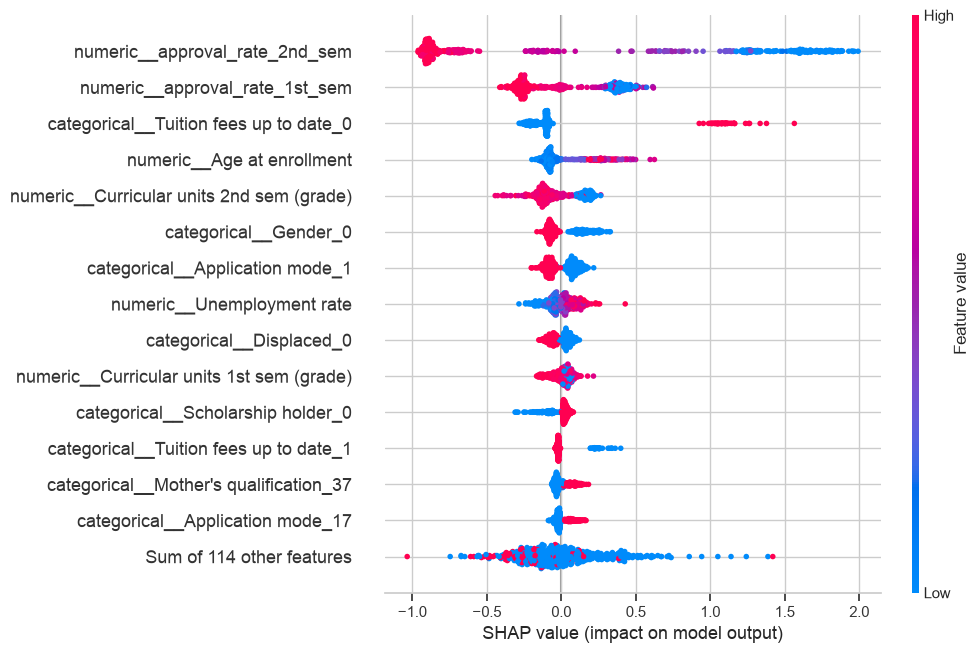

In [19]:
import shap

# Class index 0 is "Dropout" (see final_pipeline's model.classes_ ordering) —
# the outcome an early-warning system would care about most.
dropout_class_index = list(final_pipeline.named_steps["model"].classes_).index("Dropout")
shap.plots.beeswarm(explanation[:, :, dropout_class_index], max_display=15)

### Concept: how to read the beeswarm plot above

Each dot is one student; its position shows whether that feature pushed
the "Dropout" prediction up (right, red = high feature value) or down
(left, blue = low feature value). If `approval_rate_1st_sem` /
`approval_rate_2nd_sem` and `grade_trend` show up near the top here, that
directly validates this project's feature engineering rationale from
`report/report.qmd`: a student's _trajectory_ across semesters, not just
their raw enrollment counts, is what actually drives the model's
predictions — record the actual top features you see here in the report's
Discussion section.


## Concepts covered — a recap

- ✅ Exploratory Data Analysis (EDA)
- ✅ Class imbalance, and precision / recall / F1 / macro-averaging
- ✅ Missing-value handling and categorical (one-hot) encoding
- ✅ Feature engineering
- ✅ Overfitting, underfitting, k-fold cross-validation, and data leakage
- ✅ Linear models (Logistic Regression)
- ✅ Decision trees, bagging (Random Forest), and boosting (Gradient
  Boosting family)
- ✅ Confusion matrices and per-class metrics
- ✅ Hyperparameters vs. learned parameters
- ✅ Class-imbalance correction with ADASYN
- ✅ Ensemble learning: bagging vs. boosting vs. stacking, out-of-fold
  predictions
- ✅ Model interpretability with SHAP

## Next steps

- Run `python scripts/make_submission.py` to generate a Kaggle-submittable
  `submission.csv` from this same saved pipeline.
- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- If Section 10's sweep or Section 12's stacking comparison recommends a
  different final model than the default (HistGradientBoosting), retrain
  and re-save it: `python scripts/train.py --model <name>` or
  `python scripts/train.py --stacking` (see `python scripts/train.py --help`),
  optionally with `--resample` if Section 11 showed ADASYN helping.
- Fill in the Results table, the class-imbalance/ensembling/interpretability
  discussion, and finalize `report/report.qmd` with the actual numbers and
  SHAP findings from this run.
